# 02 — Data acquisition

This notebook downloads the raw CropNet Sentinel-2 imagery and the USDA corn-yield labels, then builds the three master parquets used by every downstream notebook.

**Purpose / inputs / outputs / runtime**

- **Purpose:** pull every CropNet AG / NDVI HDF5 file and every USDA Corn CSV from HuggingFace, then derive `county_index.parquet`, `yield_county_year.parquet`, and `crd_lookup.parquet`.
- **Inputs:** a HuggingFace token (recommended for higher rate limits, see the HF-auth section below) and a target drive with enough free space (see the table below).
- **Outputs:** raw imagery in `data/raw/cropnet/...`, USDA CSVs in `data/raw/cropnet/USDA Crop Dataset/...`, derived parquets in `data/processed/`.
- **Runtime:** CPU only. Wall time is dominated by the imagery downloads (one-time, idempotent).

**Two scope passes — pick based on free disk space**

The notebook is structured as two passes that can be run independently. The original three-state pass is enough to reproduce the early experiments; the expanded seven-state pass is what the rest of the project (Geo-SimCLR pre-training, probes, visualization) actually uses.

| Pass                       | States                  | AG imagery               | NDVI imagery             | Imagery total           |
|----------------------------|-------------------------|--------------------------|--------------------------|-------------------------|
| Initial 3-state pass       | IA, IL, IN              | 39.14 GB (36 files)      | 39.09 GB (36 files)      | **~78 GB**              |
| Expanded 7-state pass      | + MN, NE, OH, SD        | + 89.98 GB (48 files)    | + 90.23 GB (48 files)    | **+180 GB → ~258 GB total** |

The seven-state pass also pulls a few GB of WRF-HRRR weather CSVs and the soybean USDA labels (kept for completeness; not used in the headline pipeline).

**Spectral note.** The CropNet "NDVI" tiles are quantized B04 (Red) + B08 (NIR) at uint8 with about five reflectance levels per channel, so we recompute proper per-pixel NDVI as `(Ch1 - Ch0) / (Ch1 + Ch0 + 1e-3)` downstream in `03_baselines_data.ipynb`. The AG tiles are the three-band stack (B02 Blue, B08 NIR, B11 SWIR1) and feed the Geo-SimCLR pre-training in `04_geosimclr.ipynb`.

**Idempotent re-runs.** Every download cell skips files already on disk via HuggingFace's local cache, so it is always safe to re-run.

**Outputs consumed by downstream notebooks:**

- `data/raw/cropnet/Sentinel-2 Imagery/data/AG/...` — raw AG HDF5s (36 files at 3-state, 84 at 7-state)
- `data/raw/cropnet/Sentinel-2 Imagery/data/NDVI/...` — raw NDVI HDF5s (same counts)
- `data/raw/cropnet/USDA Crop Dataset/Corn/...` — six annual USDA Corn CSVs
- `data/processed/county_index.parquet` — `(state, fips, year, biweek, n_grids, h5_path, ...)` master tile index
- `data/processed/yield_county_year.parquet` — county-year corn-yield labels with `asd_code` (Crop Reporting District)
- `data/processed/crd_lookup.parquet` — `(fips, asd_code, asd_desc)` for CRD-aware sampling in `04_geosimclr.ipynb`

In [1]:
"""
Cell 1 — Imports, paths, configuration.

Run this cell first; everything below depends on the constants defined here.
"""
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
# Use plain text-based tqdm: ipywidgets-based bars (tqdm.auto / tqdm.notebook) do not
# render reliably in Cursor's notebook viewer. Plain tqdm prints text progress instead.
from tqdm import tqdm
from huggingface_hub import hf_hub_download

# Project root = parent of the notebooks folder (resolves regardless of where Jupyter is launched)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "cropnet"
DATA_PROC = ROOT / "data" / "processed"
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)

print("ROOT      :", ROOT)
print("DATA_RAW  :", DATA_RAW)
print("DATA_PROC :", DATA_PROC)

# CropNet HuggingFace repo
HF_REPO = "CropNet/CropNet"
HF_REPO_TYPE = "dataset"

# Seven-state Corn Belt scope (top-7 corn-producing states; the original three-state version was
# IA + IL + IN). The four added states are gated separately under STAGE2_STATES further down so
# the early three-state cells can run in isolation.
STATES = {
    "IA": {"fips": 19, "name": "Iowa"},
    "IL": {"fips": 17, "name": "Illinois"},
    "IN": {"fips": 18, "name": "Indiana"},
    "MN": {"fips": 27, "name": "Minnesota"},
    "NE": {"fips": 31, "name": "Nebraska"},
    "OH": {"fips": 39, "name": "Ohio"},
    "SD": {"fips": 46, "name": "South Dakota"},
}
YEARS = [2017, 2018, 2019, 2020, 2021, 2022]

# Each AG/NDVI HDF5 file in CropNet covers one quarter. We want the Apr-Sep growing season,
# which spans Q2 (Apr-Jun) + Q3 (Jul-Sep). We pull NDVI for both Q2 + Q3 (the full 12 biweeks
# per year) so that the same files feed both the peak-NDVI scalar baseline and the stronger
# biweekly-NDVI time-series baseline computed in 03_baselines_data.ipynb.
QUARTERS_AG = ["Q2", "Q3"]   # full growing season
QUARTERS_NDVI = ["Q2", "Q3"] # full growing season -- biweekly + peak both derivable downstream

# Quarter date ranges (used to build the HF filename)
QUARTER_DATES = {
    "Q1": ("01-01", "03-31"),
    "Q2": ("04-01", "06-30"),
    "Q3": ("07-01", "09-30"),
    "Q4": ("10-01", "12-31"),
}

print()
print("Stage 1 scope:", len(STATES), "states ×", len(YEARS), "years")
print("AG quarters  :", QUARTERS_AG, "(=", len(QUARTERS_AG) * 6, "biweeks per (state, year))")
print("NDVI quarters:", QUARTERS_NDVI, "(=", len(QUARTERS_NDVI) * 6, "biweeks per (state, year), full growing season)")

ROOT      : d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial
DATA_RAW  : d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\raw\cropnet
DATA_PROC : d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed

Stage 1 scope: 3 states × 6 years
AG quarters  : ['Q2', 'Q3'] (= 12 biweeks per (state, year))
NDVI quarters: ['Q2', 'Q3'] (= 12 biweeks per (state, year), full growing season)


## 1. Build the target file list and disk-space estimate

Each CropNet AG / NDVI HDF5 file covers one (state, year, quarter). File names follow:

```
Sentinel-2 Imagery/data/<AG|NDVI>/<year>/<state>/<Agriculture|Vegetation>_<state_fips>_<state>_<YYYY-MM-DD>_<YYYY-MM-DD>.h5
```

We list all target paths below and estimate disk usage based on the sanity-check download (Iowa Q3 2018 AG was **1.18 GB**).

In [2]:
"""
Cell 2 — Build target file lists.
"""

def build_target_files(image_type: str, quarters: list) -> list[dict]:
    """List every (image_type, year, state, quarter) HDF5 file we want to download.

    image_type: "AG" or "NDVI" (CropNet uses 'NDVI' in folder names but 'Vegetation_' in filenames)
    quarters  : subset of ['Q1','Q2','Q3','Q4'] (we use Q2+Q3 for AG, Q3 for NDVI)

    Returns a list of dicts with keys: hf_path, local_path, image_type, year, state, quarter.
    """
    prefix = "Agriculture" if image_type == "AG" else "Vegetation"
    folder = "AG" if image_type == "AG" else "NDVI"
    targets = []
    for state, meta in STATES.items():
        for year in YEARS:
            for q in quarters:
                d_start, d_end = QUARTER_DATES[q]
                fname = f"{prefix}_{meta['fips']:02d}_{state}_{year}-{d_start}_{year}-{d_end}.h5"
                hf_path = f"Sentinel-2 Imagery/data/{folder}/{year}/{state}/{fname}"
                local_path = DATA_RAW / hf_path
                targets.append(dict(
                    hf_path=hf_path,
                    local_path=local_path,
                    image_type=image_type,
                    year=year,
                    state=state,
                    quarter=q,
                ))
    return targets


ag_targets = build_target_files("AG", QUARTERS_AG)
ndvi_targets = build_target_files("NDVI", QUARTERS_NDVI)

print(f"AG   targets: {len(ag_targets)}  (3 states × 5 years × {len(QUARTERS_AG)} quarters)")
print(f"NDVI targets: {len(ndvi_targets)}  (3 states × 5 years × {len(QUARTERS_NDVI)} quarters)")
print()

# Disk usage estimate (refined after first download: AG ~1.0 GB/file, NDVI ~1.0 GB/file).
AG_GB_PER_FILE = 1.0
NDVI_GB_PER_FILE = 1.0
est_ag_gb = len(ag_targets) * AG_GB_PER_FILE
est_ndvi_gb = len(ndvi_targets) * NDVI_GB_PER_FILE
print(f"Estimated AG download   : {est_ag_gb:.1f} GB ({len(ag_targets)} files)")
print(f"Estimated NDVI download : {est_ndvi_gb:.1f} GB ({len(ndvi_targets)} files)")
print(f"Total estimated         : {est_ag_gb + est_ndvi_gb:.1f} GB")
print()

# What's already on disk?
ag_present = sum(1 for t in ag_targets if t["local_path"].exists())
ndvi_present = sum(1 for t in ndvi_targets if t["local_path"].exists())
ag_to_get = len(ag_targets) - ag_present
ndvi_to_get = len(ndvi_targets) - ndvi_present
print(f"Already on disk: {ag_present}/{len(ag_targets)} AG, {ndvi_present}/{len(ndvi_targets)} NDVI")
print(f"To download    : {ag_to_get} AG (~{ag_to_get * AG_GB_PER_FILE:.1f} GB), {ndvi_to_get} NDVI (~{ndvi_to_get * NDVI_GB_PER_FILE:.1f} GB)")

AG   targets: 36  (3 states × 5 years × 2 quarters)
NDVI targets: 36  (3 states × 5 years × 2 quarters)

Estimated AG download   : 36.0 GB (36 files)
Estimated NDVI download : 36.0 GB (36 files)
Total estimated         : 72.0 GB

Already on disk: 36/36 AG, 36/36 NDVI
To download    : 0 AG (~0.0 GB), 0 NDVI (~0.0 GB)


## 2. Disk-space precheck

Make sure the target drive has enough free space before kicking off the download. The cell below adds a 10 GB safety margin on top of the 3-state-pass requirement (~78 GB); if you intend to also run the 7-state pass at the bottom of the notebook, plan for ~270 GB total.

In [3]:
"""
Cell 3 — Disk-space precheck.

Aborts (raises) if free space < required + 10 GB safety.
"""
import shutil

drive_root = Path(DATA_RAW.drive + "\\") if DATA_RAW.drive else Path("/")
disk = shutil.disk_usage(drive_root)
free_gb = disk.free / 1e9
required_gb = est_ag_gb + est_ndvi_gb + 10  # +10 GB safety margin

print(f"Drive             : {drive_root}")
print(f"Free space        : {free_gb:.1f} GB")
print(f"Required (+ 10 GB): {required_gb:.1f} GB")
print(f"OK                : {free_gb >= required_gb}")
assert free_gb >= required_gb, f"Not enough free space on {drive_root}"

Drive             : d:\
Free space        : 204.4 GB
Required (+ 10 GB): 82.0 GB
OK                : True


It is quicker with HuggingFace authentication token.


## 3. Download AG tiles (~39 GB at the 3-state scope)

36 files at ~1.1 GB each, ~75 s per file in our sanity test, so ~45 minutes total at the 3-state scope. Idempotent: HuggingFace's `hf_hub_download` skips files already on disk, so it is safe to re-run after an interruption.

A `tqdm` bar shows per-file progress.

In [4]:
"""
Cell 4 — AG download.

Downloads each target into data/raw/cropnet/<hf_path>. Skips if file already exists.
"""

def download_targets(targets: list[dict], desc: str):
    """Download a list of targets, skipping ones already on disk. Returns a list of (hf_path, size_gb)."""
    sizes = []
    bar = tqdm(targets, desc=desc, unit="file")
    for t in bar:
        if t["local_path"].exists():
            sz = t["local_path"].stat().st_size
            bar.set_postfix(file=t["local_path"].name[:40], status="skip", size_gb=f"{sz/1e9:.2f}")
            sizes.append((t["hf_path"], sz / 1e9))
            continue
        # Download into data/raw/cropnet so the local_dir mirrors the HF path structure
        local_dir = str(DATA_RAW)
        try:
            local_path = hf_hub_download(
                repo_id=HF_REPO,
                filename=t["hf_path"],
                repo_type=HF_REPO_TYPE,
                local_dir=local_dir,
            )
            sz = Path(local_path).stat().st_size
            sizes.append((t["hf_path"], sz / 1e9))
            bar.set_postfix(file=Path(local_path).name[:40], status="ok", size_gb=f"{sz/1e9:.2f}")
        except Exception as e:
            print(f"  FAILED {t['hf_path']}: {e}")
            sizes.append((t["hf_path"], -1.0))
    return sizes


ag_sizes = download_targets(ag_targets, desc="AG tiles")
total_ag_gb = sum(s for _, s in ag_sizes if s > 0)
print(f"\nDone. Total AG on disk: {total_ag_gb:.2f} GB ({sum(1 for _, s in ag_sizes if s > 0)}/{len(ag_targets)} files)")

AG tiles:   0%|          | 0/36 [00:00<?, ?file/s, file=Agriculture_18_IN_2019-07-01_2019-09-30., size_gb=0.73, status=skip]

AG tiles: 100%|██████████| 36/36 [00:00<00:00, 1056.57file/s, file=Agriculture_18_IN_2022-07-01_2022-09-30., size_gb=0.73, status=skip]


Done. Total AG on disk: 39.14 GB (36/36 files)


## 4. Download NDVI for the full growing season (~39 GB at the 3-state scope)

Q2 + Q3 (Apr–Sep) — same biweekly cadence as the AG tiles. We do **not** train on NDVI tiles; they feed two hand-crafted NDVI baselines built downstream in `03_baselines_data.ipynb`:

- **Peak-NDVI baseline** (1 scalar per county-year): mean NDVI over the (Aug 1, Aug 15) biweeks. Standard remote-sensing yield baseline.
- **Biweekly-NDVI series baseline** (12 scalars per county-year): mean NDVI per biweek for the full Apr–Sep window. The 12-feature biweekly NDVI series is the strongest tabular non-DL comparator in our experiments.

We initially downloaded Q3-only and recovered just the peak-NDVI scalar; pulling the full Q2 + Q3 was an inexpensive upgrade that lets the same on-disk files feed both baselines without a second download phase. If you previously ran with `QUARTERS_NDVI = ["Q3"]`, the cell below skips files already on disk and only downloads the missing Q2 files.

In [5]:
"""
Cell 5 — NDVI peak download.
"""
ndvi_sizes = download_targets(ndvi_targets, desc="NDVI tiles (peak Q3)")
total_ndvi_gb = sum(s for _, s in ndvi_sizes if s > 0)
print(f"\nDone. Total NDVI on disk: {total_ndvi_gb:.2f} GB ({sum(1 for _, s in ndvi_sizes if s > 0)}/{len(ndvi_targets)} files)")

NDVI tiles (peak Q3): 100%|██████████| 36/36 [00:00<00:00, 1044.95file/s, file=Vegetation_18_IN_2022-07-01_2022-09-30.h, size_gb=0.73, status=skip]


Done. Total NDVI on disk: 39.09 GB (36/36 files)


## 5. Sanity-inspect the HDF5 structure

The CropNet AG/NDVI files are organized as:

```
<FIPS_county>/<YYYY-MM-DD>/data         shape=(G, 224, 224, 3) dtype=uint8     (G=grids per county)
<FIPS_county>/<YYYY-MM-DD>/coordinates  shape=(G, 2, 2)        dtype=float64   (lat/lon corners)
<FIPS_county>/<YYYY-MM-DD>/county       shape=(1,)             dtype=object
<FIPS_county>/<YYYY-MM-DD>/state        shape=(1,)             dtype=object
```

**For AG:** the 3 channels are `(B02 Blue, B08 NIR, B11 SWIR1)` per CropNet paper Section 3.3 — *not* visible RGB. NIR is the bright vegetation channel.

We pick one IA Q3 2018 file and one county to verify shapes, plot a sample tile, and inspect dtype/value ranges.

In [6]:
"""
Cell 6 — Inspect a sample AG file: print structure, value ranges, plot a tile.

Run after AG download finishes. Sanity check that band order matches paper (B02/B08/B11).
"""
sample = next((t for t in ag_targets if t["state"] == "IA" and t["year"] == 2018 and t["quarter"] == "Q3"), None)
assert sample is not None and sample["local_path"].exists(), \
    "Need to download IA Q3 2018 AG first."

with h5py.File(sample["local_path"], "r") as f:
    fips_keys = list(f.keys())
    print(f"FIPS in file: {len(fips_keys)} (first 5 = {fips_keys[:5]})")
    fips0 = fips_keys[0]
    dates = list(f[fips0].keys())
    print(f"Dates per FIPS: {dates}")
    
    # Inspect one (FIPS, date) group
    g = f[fips0][dates[2]]  # mid-quarter biweek (e.g. 2018-08-01)
    data = g["data"][...]   # (G, 224, 224, 3) uint8
    coords = g["coordinates"][...]
    county = g["county"][0].decode() if isinstance(g["county"][0], bytes) else str(g["county"][0])
    state = g["state"][0].decode() if isinstance(g["state"][0], bytes) else str(g["state"][0])
    
    print(f"\nSample: FIPS={fips0}, date={dates[2]}, county={county}, state={state}")
    print(f"data shape : {data.shape} dtype={data.dtype}")
    print(f"data range : min={data.min()}, max={data.max()}, mean={data.mean():.2f}")
    print(f"coords shape: {coords.shape}, sample (first grid)=\n{coords[0]}")
    print(f"per-channel mean (Blue, NIR, SWIR1): {data.mean(axis=(0,1,2))}")

FIPS in file: 99 (first 5 = ['19001', '19003', '19005', '19007', '19009'])
Dates per FIPS: ['2018-07-01', '2018-07-15', '2018-08-01', '2018-08-15', '2018-09-01', '2018-09-15']

Sample: FIPS=19001, date=2018-08-01, county=ADAIR, state=IOWA
data shape : (12, 224, 224, 3) dtype=uint8
data range : min=0, max=255, mean=143.13
coords shape: (12, 2, 2), sample (first grid)=
[[ 41.38847667 -94.700629  ]
 [ 41.504148   -94.58587   ]]
per-channel mean (Blue, NIR, SWIR1): [140.19197093 215.93445406  73.26669955]


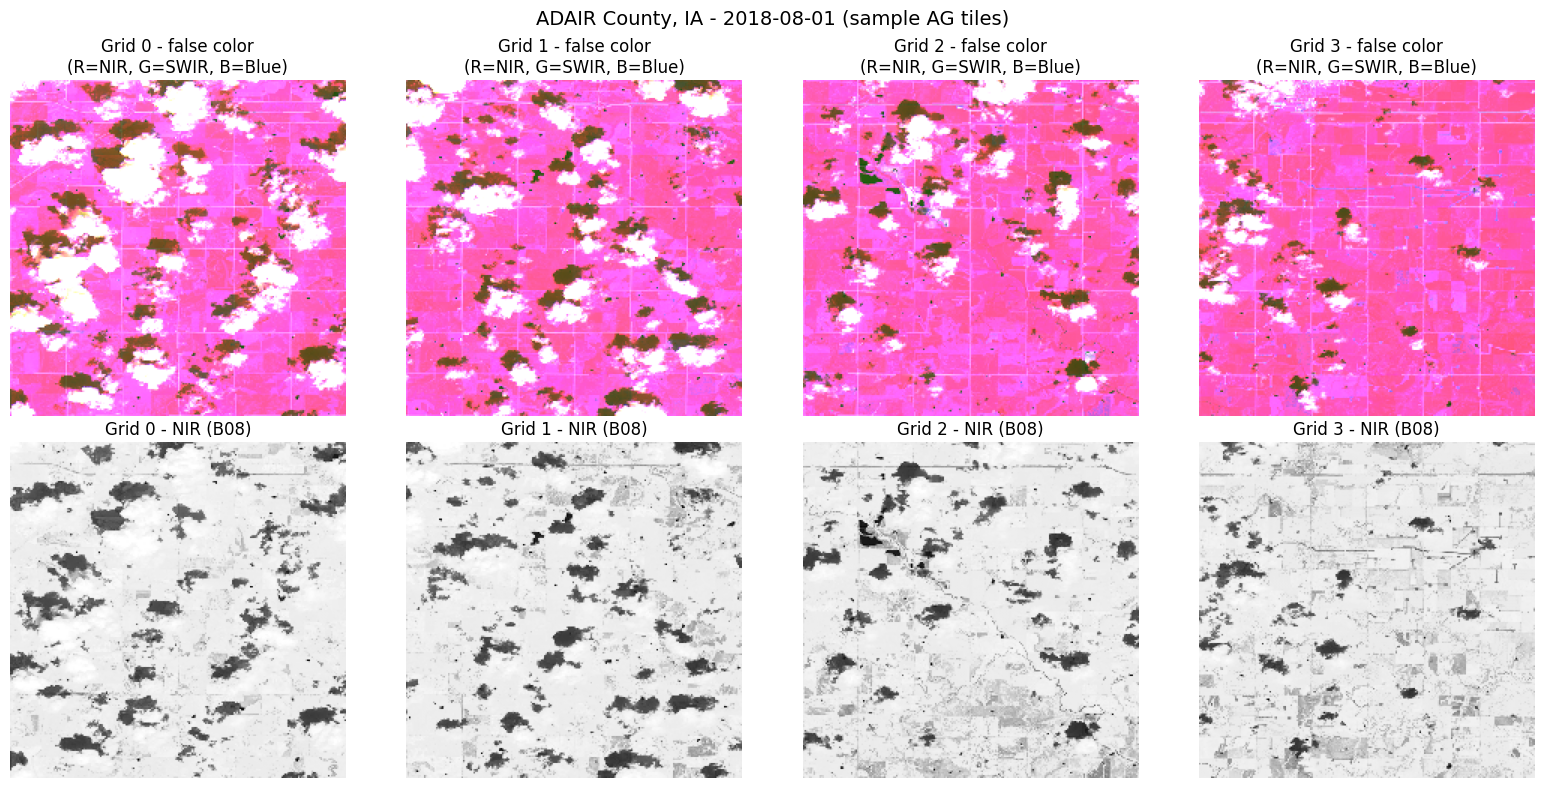

In [7]:
"""
Cell 7 — Visualize a sample AG tile.

NIR channel is bright over healthy vegetation. SWIR1 is sensitive to water content (dark over moist canopy).
"""
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Pick the first county and show its first 4 grids at the mid-quarter biweek
with h5py.File(sample["local_path"], "r") as f:
    fips0 = list(f.keys())[0]
    dates = list(f[fips0].keys())
    g = f[fips0][dates[2]]
    data = g["data"][...]
    county = g["county"][0].decode() if isinstance(g["county"][0], bytes) else str(g["county"][0])

n_show = min(4, data.shape[0])
for i in range(n_show):
    tile = data[i]  # (224, 224, 3) -- channels = (B02 Blue, B08 NIR, B11 SWIR1)

    # Top row: false-color composite (NIR, SWIR1, Blue) -> standard agri composite
    rgb = tile.astype(np.float32) / 255.0
    # Display as (R=NIR, G=SWIR1, B=Blue) so vegetation looks bright red-orange
    composite = np.stack([rgb[..., 1], rgb[..., 2], rgb[..., 0]], axis=-1)  # NIR/SWIR/Blue
    axes[0, i].imshow(np.clip(composite * 1.5, 0, 1))  # mild brightness boost for visibility
    axes[0, i].set_title(f"Grid {i} - false color\n(R=NIR, G=SWIR, B=Blue)")
    axes[0, i].axis("off")

    # Bottom row: per-channel
    axes[1, i].imshow(rgb[..., 1], cmap="gray")  # NIR alone
    axes[1, i].set_title(f"Grid {i} - NIR (B08)")
    axes[1, i].axis("off")

fig.suptitle(f"{county} County, IA - {dates[2]} (sample AG tiles)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Build `county_index.parquet` — the tile-level index

This is the master index that downstream notebooks (`04_geosimclr.ipynb`, `05_extract_and_probe.ipynb`) use to enumerate all available tiles. Each row is one **(state, fips, year, biweek)** with the following columns:

| column | type | meaning |
|---|---|---|
| `state` | str | two-letter abbreviation (IA, IL, IN at the 3-state scope; + MN, NE, OH, SD at the 7-state scope) |
| `state_fips` | int | 17, 18, 19, 27, 31, 39, 46 |
| `fips` | int | full 5-digit county FIPS (`state_fips × 1000 + county_ansi`) |
| `county` | str | county name |
| `year` | int | 2017–2022 (six years) |
| `biweek` | str | "2017-04-01", "2017-04-15", ... (12 per (county, year), Q2 + Q3) |
| `image_type` | str | "AG" |
| `n_grids` | int | number of 9 km × 9 km grids in this county-biweek tile (varies by county area) |
| `h5_path` | str | relative path to the source HDF5 file |
| `month` | int | 4–9 |
| `is_growing_season` | bool | always True for our scope |
| `is_peak_ndvi` | bool | True if biweek in (Aug-1, Aug-15) — used by the peak-NDVI baseline |

We walk every downloaded AG file and enumerate the (FIPS, date) groups inside.

**Staleness detection:** if a previously-saved `county_index.parquet` doesn't include all the years currently in `YEARS`, the cell rebuilds it (e.g. when 2017 is added to a previously 2018–2022 parquet, the existing one is detected as stale). The Stage-2 expansion section below adds an analogous state-coverage staleness check.

In [8]:
"""
Build county_index.parquet.

Walks every downloaded AG HDF5, enumerates (FIPS, date) groups, and writes a tabular index.

Staleness detection: if the existing parquet doesn't include all years currently in YEARS, we
rebuild it. The Stage-2 expansion section below adds an analogous state-coverage check.
"""
COUNTY_INDEX_PATH = DATA_PROC / "county_index.parquet"

# Decide whether to rebuild
needs_rebuild = True
if COUNTY_INDEX_PATH.exists():
    existing = pd.read_parquet(COUNTY_INDEX_PATH)
    existing_years = set(existing["year"].astype(int).unique())
    target_years = set(YEARS)
    if target_years.issubset(existing_years):
        df = existing
        print(f"county_index.parquet already covers all {len(target_years)} target years. Loading existing ({len(df):,} rows).")
        needs_rebuild = False
    else:
        missing = sorted(target_years - existing_years)
        print(f"county_index.parquet is stale: missing years {missing}. Rebuilding.")

if needs_rebuild:
    rows = []
    for t in tqdm(ag_targets, desc="Indexing AG files"):
        if not t["local_path"].exists():
            continue
        try:
            with h5py.File(t["local_path"], "r") as f:
                for fips_key in f.keys():
                    g_county = f[fips_key]
                    for date_key in g_county.keys():
                        g_date = g_county[date_key]
                        if "data" not in g_date:
                            continue
                        n_grids = g_date["data"].shape[0]
                        county = g_date["county"][0]
                        if isinstance(county, bytes):
                            county = county.decode()
                        rows.append(dict(
                            state=t["state"],
                            state_fips=STATES[t["state"]]["fips"],
                            fips=int(fips_key),
                            county=str(county),
                            year=t["year"],
                            biweek=date_key,
                            image_type="AG",
                            n_grids=int(n_grids),
                            h5_path=str(Path(t["hf_path"]).as_posix()),
                            quarter=t["quarter"],
                        ))
        except Exception as e:
            print(f"FAILED to read {t['local_path']}: {e}")
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df["month"] = df["biweek"].str.slice(5, 7).astype(int)
        df["is_growing_season"] = df["month"].between(4, 9)
        # Peak NDVI window = early/mid August (when corn is at silking/grain-fill)
        df["is_peak_ndvi"] = df["biweek"].str.slice(5, 10).isin(["08-01", "08-15"])
        df = df.sort_values(["state", "fips", "year", "biweek"]).reset_index(drop=True)
        df.to_parquet(COUNTY_INDEX_PATH, index=False)
        print(f"Saved {len(df)} rows to {COUNTY_INDEX_PATH}")
    else:
        print("No data indexed -- did the AG download finish? Re-run cell 4.")

if len(df) > 0:
    print()
    print("Index summary:")
    print(f"  total tiles : {len(df):,}")
    print(f"  states       : {sorted(df['state'].unique())}")
    print(f"  years        : {sorted(df['year'].unique())}")
    print(f"  biweeks/yr   : {df.groupby(['state','year'])['biweek'].nunique().describe()['mean']:.0f} (mean)")
    print(f"  counties/state: {df.groupby('state')['fips'].nunique().to_dict()}")
    print(f"  total grids  : {df['n_grids'].sum():,}")
    print(f"  median grids : {df['n_grids'].median():.0f}")
    print()
    print("First 5 rows:")
    print(df.head().to_string())

county_index.parquet already covers all 6 target years. Loading existing (44,140 rows).

Index summary:
  total tiles : 44,140
  states       : ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']
  years        : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
  biweeks/yr   : 12 (mean)
  counties/state: {'IA': 99, 'IL': 101, 'IN': 92, 'MN': 84, 'NE': 89, 'OH': 87, 'SD': 64}
  total grids  : 852,726
  median grids : 12

First 5 rows:
  state  state_fips   fips county  year      biweek image_type  n_grids                                                                        h5_path quarter  month  is_growing_season  is_peak_ndvi
0    IA          19  19001  ADAIR  2017  2017-04-01         AG       12  Sentinel-2 Imagery/data/AG/2017/IA/Agriculture_19_IA_2017-04-01_2017-06-30.h5      Q2      4               True         False
1    IA          19  19001  ADAIR  2017  2017-04-15         AG       12  Sentinel-2 Imagery/data/AG/2017/IA/Agriculture_19_I

## 7. Download & clean USDA Corn yields

Each `USDA_Corn_County_<year>.csv` is national (~1,500 rows, all U.S. corn-growing counties, <1 MB per file). We download all six years (2017–2022), then filter to the current state set (the 3-state set in this section; the 7-state expansion below re-runs the filter to keep all seven).

The Quick Stats columns we keep:

- `state_ansi`, `county_ansi` → combine into a 5-digit `fips` (`state_ansi × 1000 + county_ansi`)
- `state_name`, `county_name`
- `year`
- `asd_code` → **Crop Reporting District code** (used for CRD-balanced anchor sampling in `04_geosimclr.ipynb`)
- `asd_desc` → CRD human-readable name
- `YIELD, MEASURED IN BU / ACRE` → renamed to `corn_yield`
- `PRODUCTION, MEASURED IN BU` → `corn_production`

In [9]:
"""
Cell 9 — Download USDA Corn CSVs (one per year, ~5 small files).
"""
usda_paths = []
for year in YEARS:
    hf_path = f"USDA Crop Dataset/Corn/{year}/USDA_Corn_County_{year}.csv"
    local_path = DATA_RAW / hf_path
    if local_path.exists():
        usda_paths.append(local_path)
        continue
    p = hf_hub_download(repo_id=HF_REPO, filename=hf_path, repo_type=HF_REPO_TYPE, local_dir=str(DATA_RAW))
    usda_paths.append(Path(p))
    print(f"Downloaded {Path(p).name} ({Path(p).stat().st_size / 1024:.1f} KB)")

print(f"\n{len(usda_paths)} USDA Corn CSVs ready.")


6 USDA Corn CSVs ready.


In [10]:
"""
Cell 10 — Concat, filter to our 3 states, build yield_county_year.parquet.
"""
YIELD_PATH = DATA_PROC / "yield_county_year.parquet"
TARGET_STATE_FIPS = {STATES[s]["fips"] for s in STATES}

yield_frames = []
for p in usda_paths:
    yf = pd.read_csv(p)
    yield_frames.append(yf)
yield_df = pd.concat(yield_frames, ignore_index=True)
print(f"Raw USDA Corn rows (national): {len(yield_df):,}")

# Keep only our target states
yield_df = yield_df[yield_df["state_ansi"].isin(TARGET_STATE_FIPS)].copy()
print(f"After filtering to IA/IL/IN: {len(yield_df):,} rows")

# Build full FIPS code
yield_df["fips"] = yield_df["state_ansi"].astype(int) * 1000 + yield_df["county_ansi"].astype(int)

# Rename yield/production columns
yield_df = yield_df.rename(columns={
    "YIELD, MEASURED IN BU / ACRE": "corn_yield",
    "PRODUCTION, MEASURED IN BU": "corn_production",
})

# Final column order
keep_cols = [
    "fips", "year", "state_ansi", "state_name", "county_ansi", "county_name",
    "asd_code", "asd_desc", "corn_yield", "corn_production",
]
yield_df = yield_df[keep_cols].sort_values(["fips", "year"]).reset_index(drop=True)

# Sanity
print()
print(f"Yield value range: [{yield_df['corn_yield'].min():.1f}, {yield_df['corn_yield'].max():.1f}] bu/acre")
print(f"Yield NaN count  : {yield_df['corn_yield'].isna().sum()}")
print(f"Counties × years : {yield_df.groupby('state_name')['fips'].nunique().to_dict()}")

yield_df.to_parquet(YIELD_PATH, index=False)
print(f"\nSaved to {YIELD_PATH}")
yield_df.head(10)

Raw USDA Corn rows (national): 8,739
After filtering to IA/IL/IN: 1,561 rows

Yield value range: [107.3, 246.7] bu/acre
Yield NaN count  : 0
Counties × years : {'ILLINOIS': 102, 'INDIANA': 92, 'IOWA': 99}

Saved to d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed\yield_county_year.parquet


,fips,year,state_ansi,state_name,county_ansi,county_name,asd_code,asd_desc,corn_yield,corn_production
0,17001,2017,17,ILLINOIS,1,ADAMS,30,WEST,192.2,28837000.0
1,17001,2018,17,ILLINOIS,1,ADAMS,30,WEST,197.8,29075000.0
2,17001,2019,17,ILLINOIS,1,ADAMS,30,WEST,168.1,21546000.0
3,17001,2020,17,ILLINOIS,1,ADAMS,30,WEST,177.5,27189000.0
4,17001,2022,17,ILLINOIS,1,ADAMS,30,WEST,200.8,29202000.0
5,17003,2017,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,159.4,781000.0
6,17003,2018,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,188.4,1262000.0
7,17003,2019,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,144.2,476000.0
8,17003,2020,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,181.7,1192000.0
9,17003,2022,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,162.2,767000.0


## 8. Crop Reporting District (CRD) lookup table

The CRD is USDA's `asd_code`, a 2-digit code identifying agro-climatic zones inside a state (typically 7–9 per state). We use it in `04_geosimclr.ipynb` for **CRD-balanced anchor sampling** — anchors are drawn with a `WeightedRandomSampler` whose weights are inversely proportional to each CRD's anchor count, so within-batch negatives are agro-climatically diverse on average.

We extract a clean `(fips, asd_code, asd_desc)` lookup from the USDA yield data. CRDs are stable over time, so we just take the most recent year's mapping.

In [11]:
"""
Cell 11 — Save CRD lookup.
"""
CRD_PATH = DATA_PROC / "crd_lookup.parquet"

crd_lookup = (
    yield_df[["fips", "state_ansi", "state_name", "county_name", "asd_code", "asd_desc"]]
    .drop_duplicates(subset=["fips"])
    .sort_values("fips")
    .reset_index(drop=True)
)
crd_lookup.to_parquet(CRD_PATH, index=False)
print(f"CRD lookup: {len(crd_lookup)} counties, {crd_lookup['asd_code'].nunique()} unique CRDs")
print(f"Saved to {CRD_PATH}")
print()
print("CRD distribution per state:")
print(crd_lookup.groupby(["state_name", "asd_desc"])["fips"].count().to_string())

CRD lookup: 293 counties, 9 unique CRDs
Saved to d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed\crd_lookup.parquet

CRD distribution per state:
state_name  asd_desc      
ILLINOIS    CENTRAL           11
            EAST               7
            EAST SOUTHEAST    15
            NORTHEAST         11
            NORTHWEST         12
            SOUTHEAST         12
            SOUTHWEST         12
            WEST               9
            WEST SOUTHWEST    13
INDIANA     CENTRAL           16
            EAST CENTRAL       8
            NORTH CENTRAL      9
            NORTHEAST          9
            NORTHWEST          9
            SOUTH CENTRAL     10
            SOUTHEAST          9
            SOUTHWEST         12
            WEST CENTRAL      10
IOWA        CENTRAL           12
            EAST CENTRAL      10
            NORTH CENTRAL     11
            NORTHEAST         11
            NORTHWEST         12
            SOUTH C

## 9. Quick EDA

A few sanity plots to confirm the data looks right before we build the SSL training pipeline:

1. **Yield distribution** per state and year (box plot) — should look like ~150-200 bu/acre, with year-to-year variation.
2. **Tile coverage** by state × biweek — should be uniform across counties and biweeks (any holes mean missing CropNet files).
3. **Tile counts per county** (histogram of `n_grids`) — large counties have more grids.
4. **Sample tiles** from a random county at three different biweeks — visual sanity that growth progresses through the season.

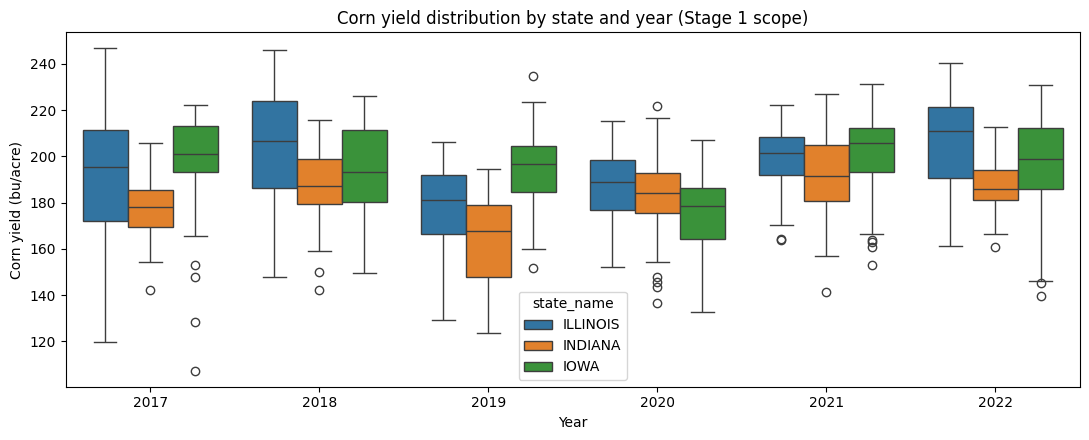

year         2017    2018    2019   2020    2021   2022
state_name                                             
ILLINOIS    195.3  206.70  181.10  188.9  201.40  211.1
INDIANA     178.0  187.15  167.50  184.3  191.60  186.0
IOWA        200.9  193.30  196.85  178.4  205.85  198.8


In [12]:
"""
Cell 12 — EDA plot 1: yield distribution per state, year.
"""
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(
    data=yield_df.dropna(subset=["corn_yield"]),
    x="year", y="corn_yield", hue="state_name", ax=ax,
)
ax.set_title("Corn yield distribution by state and year (Stage 1 scope)")
ax.set_ylabel("Corn yield (bu/acre)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

# Print the medians for quick reference
print(yield_df.groupby(["state_name", "year"])["corn_yield"].median().unstack())

Counties present per (state, year, biweek):
biweek      2017-04-01  2017-04-15  2017-05-01  2017-05-15  2017-06-01  \
state year                                                               
IA    2017          99          99          99          99          99   
      2018           0           0           0           0           0   
      2019           0           0           0           0           0   
      2020           0           0           0           0           0   
      2021           0           0           0           0           0   
      2022           0           0           0           0           0   
IL    2017         101         101         101         101         101   
      2018           0           0           0           0           0   
      2019           0           0           0           0           0   
      2020           0           0           0           0           0   
      2021           0           0           0           0          

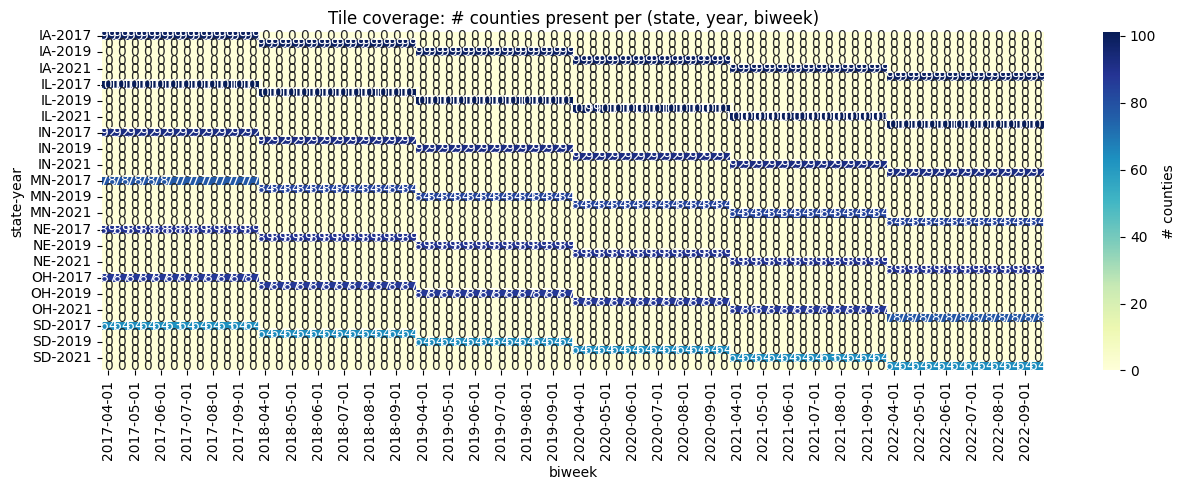

In [13]:
"""
Cell 13 — EDA plot 2: tile coverage heatmap.

Rows = (state, year), columns = biweek. Cell value = number of counties present.
A uniform color is what we want.
"""
coverage = (
    df.groupby(["state", "year", "biweek"])["fips"].nunique().reset_index(name="n_counties")
)
print("Counties present per (state, year, biweek):")
# pivot_table returns float by default (because of fill_value handling); cast to int so fmt="d" works
piv = (
    coverage.pivot_table(index=["state", "year"], columns="biweek", values="n_counties", fill_value=0)
    .astype(int)
)
print(piv)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(piv, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "# counties"}, ax=ax)
ax.set_title("Tile coverage: # counties present per (state, year, biweek)")
plt.tight_layout()
plt.show()

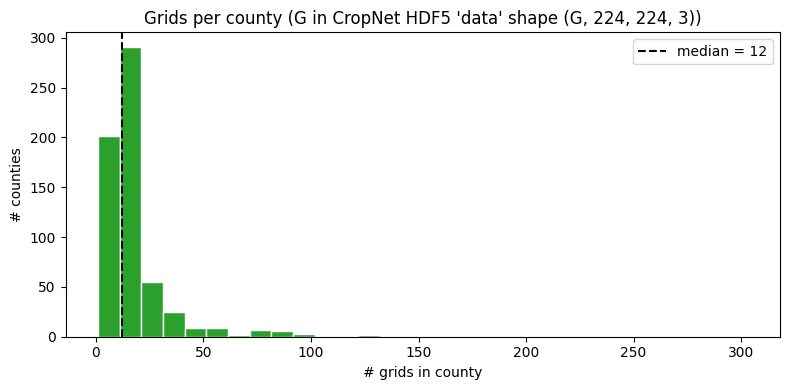

Total tiles available for SSL pretraining: 852,726
  (sum over (state, fips, year, biweek, grid))
  = (44,140 county-biweeks) x (median 12 grids)


In [14]:
"""
Cell 14 — EDA plot 3: distribution of grids per county.

Each county is partitioned into G 9x9 km grids (per CropNet paper Sec 3.3 / Figure 6).
G varies by county area. SimCLR aggregation in 05_extract_and_probe.ipynb mean-pools over grids.
"""
grids_per_county = df.groupby("fips")["n_grids"].first()  # constant per fips
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(grids_per_county.values, bins=30, color="C2", edgecolor="white")
ax.set_title(f"Grids per county (G in CropNet HDF5 'data' shape (G, 224, 224, 3))")
ax.set_xlabel("# grids in county")
ax.set_ylabel("# counties")
ax.axvline(grids_per_county.median(), color="k", linestyle="--", label=f"median = {grids_per_county.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Total tiles available for SSL pretraining: {df['n_grids'].sum():,}")
print(f"  (sum over (state, fips, year, biweek, grid))")
print(f"  = ({len(df):,} county-biweeks) x (median {grids_per_county.median():.0f} grids)")

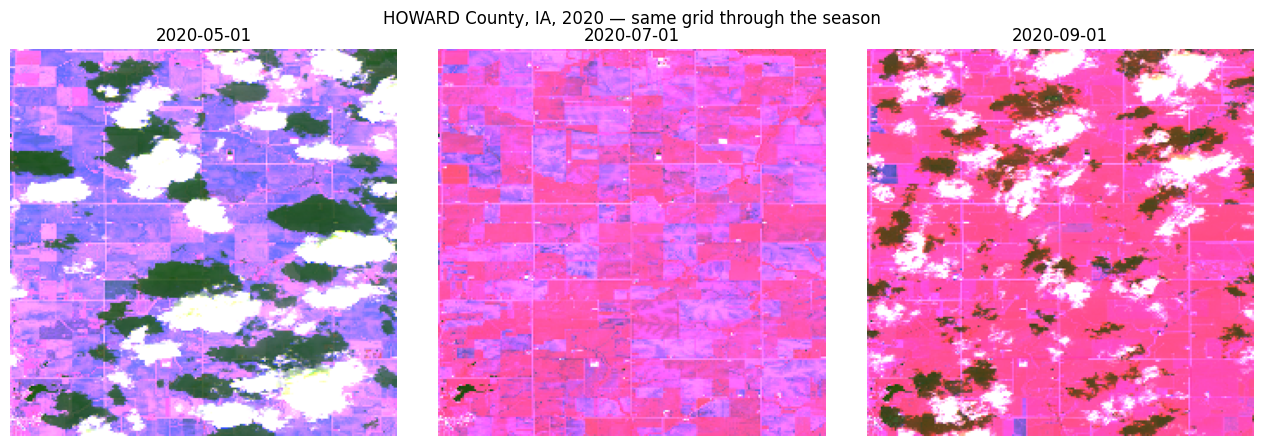

In [15]:
"""
Cell 15 — EDA plot 4: same county at different biweeks (visual sanity).

Pick a random IA county and show one grid at three different growing-season dates.
Should see canopy emerge -> peak -> senesce as biweeks progress.
"""
np.random.seed(0)
ia_index = df[(df["state"] == "IA") & (df["year"] == 2020)]
random_fips = np.random.choice(ia_index["fips"].unique())
county_index = ia_index[ia_index["fips"] == random_fips].sort_values("biweek")

biweeks_to_show = ["2020-05-01", "2020-07-01", "2020-09-01"]  # planting -> grain fill -> senescence
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, bw in zip(axes, biweeks_to_show):
    row = county_index[county_index["biweek"] == bw]
    if len(row) == 0:
        ax.text(0.5, 0.5, f"no data for {bw}", ha="center", va="center")
        ax.axis("off")
        continue
    h5_full_path = DATA_RAW / row.iloc[0]["h5_path"]
    with h5py.File(h5_full_path, "r") as f:
        g = f[str(int(random_fips))][bw]
        data = g["data"][...]
        county = g["county"][0]
        county = county.decode() if isinstance(county, bytes) else str(county)
    grid = data[0]  # show grid 0
    rgb = grid.astype(np.float32) / 255.0
    composite = np.stack([rgb[..., 1], rgb[..., 2], rgb[..., 0]], axis=-1)  # NIR/SWIR/Blue
    ax.imshow(np.clip(composite * 1.5, 0, 1))
    ax.set_title(f"{bw}")
    ax.axis("off")

fig.suptitle(f"{county} County, IA, 2020 — same grid through the season", fontsize=12)
plt.tight_layout()
plt.show()

# Expansion to seven Corn Belt states

Run the cells below to extend the dataset from the initial three-state pass (IA, IL, IN) to the seven-state pass (adds MN, NE, OH, SD) used by the rest of the project. They reuse the helpers `build_target_files` and `download_targets` defined above but operate on a separate `STAGE2_STATES` dict so re-running the earlier cells doesn't accidentally re-download the new states, and vice versa.

**What this section adds:**

1. **Four more Corn Belt states** — AG + NDVI tiles for MN, NE, OH, SD: +89.98 GB (48 AG files) and +90.23 GB (48 NDVI files), so **about +180 GB** of imagery on top of the ~78 GB already on disk.
2. **Soybean USDA yield labels** for all seven states (six annual CSVs, <1 MB total). Kept for completeness; not used in the headline pipeline.
3. **WRF-HRRR weather data** — monthly meteorological CSVs for all states × all years (a few GB total). Kept for completeness; not used in the headline pipeline.
4. **Refresh `county_index.parquet`** to include the new states' tiles, with a state-coverage staleness check analogous to the year-coverage check above.

**Total imagery on disk after running everything: about 258 GB.** Each download cell is idempotent (skip-if-exists), so partial runs are safe to retry.

In [16]:
"""
Configure the four states added in the seven-state expansion.

Edit STAGE2_STATES to control scope. The default (NE, MN, OH, SD) adds ~334 counties and
about +90 GB of AG imagery + ~90 GB of NDVI imagery (so ~180 GB total on top of the ~78 GB
already on disk from the three-state pass). Comment in/out lines as desired; each state file
is ~1.0-1.2 GB per (year, quarter).

Run this cell first to compute the size estimate, then the download cells below.
"""

# Recommended Corn Belt extension (NE, MN, OH, SD; per-state size estimates below are for
# one modality, so multiply by 2 to include both AG + NDVI).
# Counties and corn rank from USDA NASS 2022-2024.
STAGE2_STATES = {
    "NE": {"fips": 31, "name": "Nebraska",     "counties_est": 93,  "rank_corn": 3},  # ~25 GB
    "MN": {"fips": 27, "name": "Minnesota",    "counties_est": 87,  "rank_corn": 4},  # ~23 GB
    "OH": {"fips": 39, "name": "Ohio",         "counties_est": 88,  "rank_corn": 7},  # ~22 GB
    "SD": {"fips": 46, "name": "South Dakota", "counties_est": 66,  "rank_corn": 6},  # ~17 GB
    # --- Optional further additions (uncomment to include) ---
    # "MO": {"fips": 29, "name": "Missouri",     "counties_est": 115, "rank_corn": 10}, # ~28 GB; mixed corn/soy
    # "KS": {"fips": 20, "name": "Kansas",       "counties_est": 105, "rank_corn": 9},  # ~26 GB; heavy wheat
    # "ND": {"fips": 38, "name": "North Dakota", "counties_est": 53,  "rank_corn": 13}, # ~13 GB; lower corn
    # "WI": {"fips": 55, "name": "Wisconsin",    "counties_est": 72,  "rank_corn": 11}, # ~18 GB; silage corn
}

print(f"Stage 2 states selected: {list(STAGE2_STATES.keys())}")
total_counties = sum(s["counties_est"] for s in STAGE2_STATES.values())
print(f"Estimated counties added: {total_counties}")

# Build target lists for the new states using the same helper as the initial 3-state pass.
ag_targets_s2 = []
ndvi_targets_s2 = []
for state, meta in STAGE2_STATES.items():
    for year in YEARS:
        for q in QUARTERS_AG:
            d_start, d_end = QUARTER_DATES[q]
            fname = f"Agriculture_{meta['fips']:02d}_{state}_{year}-{d_start}_{year}-{d_end}.h5"
            hf_path = f"Sentinel-2 Imagery/data/AG/{year}/{state}/{fname}"
            ag_targets_s2.append(dict(
                hf_path=hf_path, local_path=DATA_RAW / hf_path,
                image_type="AG", year=year, state=state, quarter=q,
            ))
        for q in QUARTERS_NDVI:
            d_start, d_end = QUARTER_DATES[q]
            fname = f"Vegetation_{meta['fips']:02d}_{state}_{year}-{d_start}_{year}-{d_end}.h5"
            hf_path = f"Sentinel-2 Imagery/data/NDVI/{year}/{state}/{fname}"
            ndvi_targets_s2.append(dict(
                hf_path=hf_path, local_path=DATA_RAW / hf_path,
                image_type="NDVI", year=year, state=state, quarter=q,
            ))

AG_GB_PER_FILE = 1.0
NDVI_GB_PER_FILE = 1.0
ag_present = sum(1 for t in ag_targets_s2 if t["local_path"].exists())
ndvi_present = sum(1 for t in ndvi_targets_s2 if t["local_path"].exists())
ag_to_get = len(ag_targets_s2) - ag_present
ndvi_to_get = len(ndvi_targets_s2) - ndvi_present
print()
print(f"Stage 2 AG  files: {len(ag_targets_s2)} total, {ag_present} on disk, {ag_to_get} to download (~{ag_to_get * AG_GB_PER_FILE:.0f} GB)")
print(f"Stage 2 NDVI files: {len(ndvi_targets_s2)} total, {ndvi_present} on disk, {ndvi_to_get} to download (~{ndvi_to_get * NDVI_GB_PER_FILE:.0f} GB)")
print(f"Stage 2 total to download: ~{(ag_to_get + ndvi_to_get) * 1.0:.0f} GB")

import shutil
free_gb = shutil.disk_usage(Path(str(DATA_RAW.drive) + "\\")).free / 1e9
print(f"\nDisk free on {DATA_RAW.drive}: {free_gb:.1f} GB. Required + 10 GB safety: {(ag_to_get + ndvi_to_get) * 1.0 + 10:.1f} GB.")
assert free_gb >= (ag_to_get + ndvi_to_get) * 1.0 + 10, "Not enough disk space; reduce STAGE2_STATES."

Stage 2 states selected: ['NE', 'MN', 'OH', 'SD']
Estimated counties added: 334

Stage 2 AG  files: 48 total, 48 on disk, 0 to download (~0 GB)
Stage 2 NDVI files: 48 total, 48 on disk, 0 to download (~0 GB)
Stage 2 total to download: ~0 GB

Disk free on d:: 204.4 GB. Required + 10 GB safety: 10.0 GB.


In [17]:
"""
Download AG tiles for the four added states (MN, NE, OH, SD).

Reuses the `download_targets` helper defined above. Idempotent: skip-if-exists. Expect roughly
10-30 minutes depending on network speed.
"""
ag_sizes_s2 = download_targets(ag_targets_s2, desc="Stage 2 AG tiles")
total_ag_gb_s2 = sum(s for _, s in ag_sizes_s2 if s > 0)
n_ok = sum(1 for _, s in ag_sizes_s2 if s > 0)
print(f"\nStage 2 AG done. {n_ok}/{len(ag_targets_s2)} files, total {total_ag_gb_s2:.2f} GB on disk.")

Stage 2 AG tiles: 100%|██████████| 48/48 [00:00<00:00, 1120.76file/s, file=Agriculture_46_SD_2022-07-01_2022-09-30., size_gb=2.20, status=skip]


Stage 2 AG done. 48/48 files, total 89.98 GB on disk.


In [18]:
"""
Download NDVI tiles for the four added states (full Q2 + Q3 growing season).
"""
ndvi_sizes_s2 = download_targets(ndvi_targets_s2, desc="Stage 2 NDVI tiles")
total_ndvi_gb_s2 = sum(s for _, s in ndvi_sizes_s2 if s > 0)
n_ok = sum(1 for _, s in ndvi_sizes_s2 if s > 0)
print(f"\nStage 2 NDVI done. {n_ok}/{len(ndvi_targets_s2)} files, total {total_ndvi_gb_s2:.2f} GB on disk.")

Stage 2 NDVI tiles: 100%|██████████| 48/48 [00:00<00:00, 1204.34file/s, file=Vegetation_46_SD_2022-07-01_2022-09-30.h, size_gb=2.20, status=skip]


Stage 2 NDVI done. 48/48 files, total 90.23 GB on disk.


In [19]:
"""
Download USDA Soybean yields for all seven states, 2017-2022.

Tiny (~150 KB per file × 6 years = <1 MB total). Filtered to our state set, joined with
crd_lookup, and saved to data/processed/yield_soybean_county_year.parquet. Kept for completeness;
not used in the headline pipeline.
"""
SOYBEAN_YIELD_PATH = DATA_PROC / "yield_soybean_county_year.parquet"

soy_paths = []
for year in YEARS:
    hf_path = f"USDA Crop Dataset/Soybeans/{year}/USDA_Soybean_County_{year}.csv"
    local_path = DATA_RAW / hf_path
    if local_path.exists():
        soy_paths.append(local_path)
        continue
    p = hf_hub_download(repo_id=HF_REPO, filename=hf_path, repo_type=HF_REPO_TYPE, local_dir=str(DATA_RAW))
    soy_paths.append(Path(p))
    print(f"Downloaded {Path(p).name} ({Path(p).stat().st_size / 1024:.1f} KB)")
print(f"\n{len(soy_paths)} USDA Soybean CSVs ready.")

# Concat + filter to the seven-state union + clean schema
ALL_STATES = {**STATES, **STAGE2_STATES}
target_state_fips = {meta["fips"] for meta in ALL_STATES.values()}
soy_frames = [pd.read_csv(p) for p in soy_paths]
soy_df = pd.concat(soy_frames, ignore_index=True)
print(f"Raw USDA Soybean rows (national): {len(soy_df):,}")

soy_df = soy_df[soy_df["state_ansi"].isin(target_state_fips)].copy()
soy_df["fips"] = soy_df["state_ansi"].astype(int) * 1000 + soy_df["county_ansi"].astype(int)
soy_df = soy_df.rename(columns={
    "YIELD, MEASURED IN BU / ACRE": "soybean_yield",
    "PRODUCTION, MEASURED IN BU": "soybean_production",
})
keep_cols = ["fips", "year", "state_ansi", "state_name", "county_ansi", "county_name",
             "asd_code", "asd_desc", "soybean_yield", "soybean_production"]
soy_df = soy_df[keep_cols].sort_values(["fips", "year"]).reset_index(drop=True)
print(f"After filtering to {len(target_state_fips)} target states: {len(soy_df):,} rows")
print(f"Soybean yield range: [{soy_df['soybean_yield'].min():.1f}, {soy_df['soybean_yield'].max():.1f}] bu/acre")
print(f"NaN soybean yields : {soy_df['soybean_yield'].isna().sum()}")
print(f"Counties × years   : {soy_df.groupby('state_name')['fips'].nunique().to_dict()}")

soy_df.to_parquet(SOYBEAN_YIELD_PATH, index=False)
print(f"\nSaved {len(soy_df):,} rows to {SOYBEAN_YIELD_PATH}")
soy_df.head(10)


6 USDA Soybean CSVs ready.
Raw USDA Soybean rows (national): 7,795
After filtering to 7 target states: 2,973 rows
Soybean yield range: [6.9, 80.4] bu/acre
NaN soybean yields : 0
Counties × years   : {'ILLINOIS': 101, 'INDIANA': 92, 'IOWA': 99, 'MINNESOTA': 81, 'NEBRASKA': 74, 'OHIO': 86, 'SOUTH DAKOTA': 53}

Saved 2,973 rows to d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed\yield_soybean_county_year.parquet


,fips,year,state_ansi,state_name,county_ansi,county_name,asd_code,asd_desc,soybean_yield,soybean_production
0,17001,2017,17,ILLINOIS,1,ADAMS,30,WEST,55.9,7688000.0
1,17001,2018,17,ILLINOIS,1,ADAMS,30,WEST,59.3,8117000.0
2,17001,2019,17,ILLINOIS,1,ADAMS,30,WEST,49.8,6473000.0
3,17001,2020,17,ILLINOIS,1,ADAMS,30,WEST,54.8,7338000.0
4,17001,2022,17,ILLINOIS,1,ADAMS,30,WEST,61.2,8874000.0
5,17003,2017,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,42.3,1420000.0
6,17003,2020,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,48.7,1602000.0
7,17003,2021,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,57.9,2183000.0
8,17003,2022,17,ILLINOIS,3,ALEXANDER,80,SOUTHWEST,51.3,2134000.0
9,17005,2017,17,ILLINOIS,5,BOND,60,WEST SOUTHWEST,54.5,4578000.0


In [20]:
"""
Download WRF-HRRR weather data for all seven states, 2017-2022.

Files are monthly CSVs at /WRF-HRRR Computed Dataset/data/<year>/<state>/HRRR_<fips>_<state>_<year>-<MM>.csv.
Each is ~50-200 KB, 12 per (state, year). Total: 7 states × 6 years × 12 = ~500 files,
~50-150 MB total. Tiny by HDF5 standards; downloads in 1-3 minutes. Kept for completeness;
not used in the headline pipeline.
"""
ALL_STATES = {**STATES, **STAGE2_STATES}

hrrr_targets = []
for state, meta in ALL_STATES.items():
    for year in YEARS:
        for month in range(1, 13):
            fname = f"HRRR_{meta['fips']:02d}_{state}_{year}-{month:02d}.csv"
            hf_path = f"WRF-HRRR Computed Dataset/data/{year}/{state}/{fname}"
            local_path = DATA_RAW / hf_path
            hrrr_targets.append(dict(
                hf_path=hf_path, local_path=local_path,
                state=state, year=year, month=month,
            ))

n_have = sum(1 for t in hrrr_targets if t["local_path"].exists())
print(f"WRF-HRRR targets : {len(hrrr_targets)} (already on disk: {n_have}, to download: {len(hrrr_targets) - n_have})")

# Reuse download_targets which uses hf_hub_download internally
hrrr_sizes = download_targets(hrrr_targets, desc="WRF-HRRR weather")

total_hrrr_mb = sum(s * 1000 for _, s in hrrr_sizes if s > 0)
n_ok = sum(1 for _, s in hrrr_sizes if s > 0)
print(f"\nWRF-HRRR done. {n_ok}/{len(hrrr_targets)} files, total {total_hrrr_mb:.0f} MB on disk.")
print()
print("(Stage 2 head 7c (weather ablation) and 7d (weekly condition) will consume this in notebook 07.)")

WRF-HRRR targets : 504 (already on disk: 504, to download: 0)


WRF-HRRR weather:   0%|          | 0/504 [00:00<?, ?file/s, file=HRRR_19_IA_2020-07.csv, size_gb=0.01, status=skip]

WRF-HRRR weather: 100%|██████████| 504/504 [00:00<00:00, 890.27file/s, file=HRRR_46_SD_2022-12.csv, size_gb=0.01, status=skip]



WRF-HRRR done. 504/504 files, total 4620 MB on disk.

(Stage 2 head 7c (weather ablation) and 7d (weekly condition) will consume this in notebook 07.)


In [21]:
"""
Refresh county_index.parquet to cover the seven-state union.

Walks every AG file on disk (across all seven states) and rebuilds the master tile index with
a state-coverage staleness check. Safe to re-run any time.
"""
ALL_STATES = {**STATES, **STAGE2_STATES}
ALL_STATES_NAMES = set(ALL_STATES.keys())

# Detect staleness on years OR states
needs_rebuild = True
if COUNTY_INDEX_PATH.exists():
    existing = pd.read_parquet(COUNTY_INDEX_PATH)
    existing_years = set(existing["year"].astype(int).unique())
    existing_states = set(existing["state"].astype(str).unique())
    target_years = set(YEARS)
    if target_years.issubset(existing_years) and ALL_STATES_NAMES.issubset(existing_states):
        df = existing
        print(f"county_index.parquet already covers all {len(target_years)} years × {len(ALL_STATES_NAMES)} states. Loading existing ({len(df):,} rows).")
        needs_rebuild = False
    else:
        missing_years = sorted(target_years - existing_years)
        missing_states = sorted(ALL_STATES_NAMES - existing_states)
        print(f"county_index.parquet is stale: missing years {missing_years}, missing states {missing_states}. Rebuilding.")

if needs_rebuild:
    rows = []
    # Walk every state's AG files (full seven-state union)
    all_targets = []
    for state, meta in ALL_STATES.items():
        for year in YEARS:
            for q in QUARTERS_AG:
                d_start, d_end = QUARTER_DATES[q]
                fname = f"Agriculture_{meta['fips']:02d}_{state}_{year}-{d_start}_{year}-{d_end}.h5"
                hf_path = f"Sentinel-2 Imagery/data/AG/{year}/{state}/{fname}"
                local_path = DATA_RAW / hf_path
                all_targets.append(dict(state=state, year=year, quarter=q,
                                        hf_path=hf_path, local_path=local_path))

    n_files_seen = 0
    for t in tqdm(all_targets, desc="Indexing AG files"):
        if not t["local_path"].exists():
            continue
        n_files_seen += 1
        try:
            with h5py.File(t["local_path"], "r") as f:
                for fips_key in f.keys():
                    try:
                        g_county = f[fips_key]
                        for date_key in g_county.keys():
                            try:
                                g_date = g_county[date_key]
                                if "data" not in g_date:
                                    continue
                                n_grids = g_date["data"].shape[0]
                                county = g_date["county"][0]
                                if isinstance(county, bytes):
                                    county = county.decode()
                                rows.append(dict(
                                    state=t["state"],
                                    state_fips=ALL_STATES[t["state"]]["fips"],
                                    fips=int(fips_key),
                                    county=str(county),
                                    year=t["year"],
                                    biweek=date_key,
                                    image_type="AG",
                                    n_grids=int(n_grids),
                                    h5_path=str(Path(t["hf_path"]).as_posix()),
                                    quarter=t["quarter"],
                                ))
                            except Exception as e:
                                pass  # skip bad biweeks
                    except Exception as e:
                        pass  # skip bad FIPS
        except Exception as e:
            print(f"FAILED to read {t['local_path'].name}: {e}")

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df["month"] = df["biweek"].str.slice(5, 7).astype(int)
        df["is_growing_season"] = df["month"].between(4, 9)
        df["is_peak_ndvi"] = df["biweek"].str.slice(5, 10).isin(["08-01", "08-15"])
        df = df.sort_values(["state", "fips", "year", "biweek"]).reset_index(drop=True)
        df.to_parquet(COUNTY_INDEX_PATH, index=False)
        print(f"\nSaved {len(df):,} rows to {COUNTY_INDEX_PATH}")
        print(f"Walked {n_files_seen} AG files.")
    else:
        print("\nNo data indexed. Did the AG download finish?")

if len(df) > 0:
    print()
    print("Updated index summary:")
    print(f"  total tiles : {len(df):,}")
    print(f"  states       : {sorted(df['state'].unique())}")
    print(f"  years        : {sorted(df['year'].unique())}")
    print(f"  counties/state: {df.groupby('state')['fips'].nunique().to_dict()}")
    print(f"  total grids  : {df['n_grids'].sum():,}")
    print(f"  median grids/county: {df['n_grids'].median():.0f}")

county_index.parquet already covers all 6 years × 7 states. Loading existing (44,140 rows).

Updated index summary:
  total tiles : 44,140
  states       : ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']
  years        : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
  counties/state: {'IA': 99, 'IL': 101, 'IN': 92, 'MN': 84, 'NE': 89, 'OH': 87, 'SD': 64}
  total grids  : 852,726
  median grids/county: 12


## 8b. Refresh CRD lookup + corn-yield labels for all seven states

Section 8 above wrote `crd_lookup.parquet` and `yield_county_year.parquet` filtered to the initial three-state scope (IA, IL, IN). Once the four new states have been downloaded by the cells above, the downstream notebooks need those parquets refreshed to cover the full seven-state union.

This cell idempotently rebuilds **both parquets** by re-reading every USDA Corn CSV on disk and re-filtering to `STATES ∪ STAGE2_STATES`. It overwrites `data/processed/yield_county_year.parquet` and `data/processed/crd_lookup.parquet` in place.

**Outputs after this cell (verified in the printed cell output below):**
- `data/processed/yield_county_year.parquet` — corn-yield labels for all seven states (3,126 rows).
- `data/processed/crd_lookup.parquet` — `(fips, state_ansi, state_name, county_name, asd_code, asd_desc)` for all seven states (616 counties, 61 unique CRDs).

**Consumed by:** notebook 04 (CRD-balanced anchor sampler), notebook 05 (corn-yield probe), notebook 06 (per-county-year yield labels). Skip if `STAGE2_STATES` is empty.

In [22]:
"""
Refresh yield_county_year.parquet + crd_lookup.parquet to cover all seven states.

Re-reads every USDA Corn CSV on disk, filters to the union STATES + STAGE2_STATES, and overwrites
both parquets in place. Idempotent and safe to re-run.
"""

ALL_STATE_FIPS = {meta["fips"] for meta in STATES.values()} | {meta["fips"] for meta in STAGE2_STATES.values()}
ALL_STATE_ABBR = sorted(set(STATES.keys()) | set(STAGE2_STATES.keys()))
print(f"Stage 1 + Stage 2 states: {ALL_STATE_ABBR}  (state_ansi = {sorted(ALL_STATE_FIPS)})")

corn_csvs = sorted((DATA_RAW / "USDA Crop Dataset" / "Corn").glob("*/USDA_Corn_County_*.csv"))
assert corn_csvs, f"No USDA Corn CSVs found under {DATA_RAW / 'USDA Crop Dataset' / 'Corn'}/. Run the USDA download cell in Section 7 above first."
print(f"Reading {len(corn_csvs)} USDA Corn CSVs...")

frames = []
for p in corn_csvs:
    frames.append(pd.read_csv(p))
yield_all = pd.concat(frames, ignore_index=True)
print(f"  raw national rows: {len(yield_all):,}")

yield_all = yield_all[yield_all["state_ansi"].astype(int).isin(ALL_STATE_FIPS)].copy()
print(f"  after filtering to 7 states: {len(yield_all):,} rows")

yield_all["fips"] = yield_all["state_ansi"].astype(int) * 1000 + yield_all["county_ansi"].astype(int)
yield_all = yield_all.rename(columns={
    "YIELD, MEASURED IN BU / ACRE": "corn_yield",
    "PRODUCTION, MEASURED IN BU": "corn_production",
})
keep_cols = [
    "fips", "year", "state_ansi", "state_name", "county_ansi", "county_name",
    "asd_code", "asd_desc", "corn_yield", "corn_production",
]
yield_all = yield_all[keep_cols].sort_values(["fips", "year"]).reset_index(drop=True)

YIELD_PATH = DATA_PROC / "yield_county_year.parquet"
yield_all.to_parquet(YIELD_PATH, index=False)
print(f"\nyield_county_year.parquet refreshed -> {YIELD_PATH}")
print(f"  rows: {len(yield_all):,}")
print(f"  yield range: [{yield_all['corn_yield'].min():.1f}, {yield_all['corn_yield'].max():.1f}] bu/acre  (NaN: {yield_all['corn_yield'].isna().sum()})")
print(f"  counties per state:")
print(yield_all.groupby("state_name")["fips"].nunique().to_string())

crd_lookup_all = (
    yield_all[["fips", "state_ansi", "state_name", "county_name", "asd_code", "asd_desc"]]
    .drop_duplicates(subset=["fips"])
    .sort_values("fips")
    .reset_index(drop=True)
)
CRD_PATH = DATA_PROC / "crd_lookup.parquet"
crd_lookup_all.to_parquet(CRD_PATH, index=False)
print(f"\ncrd_lookup.parquet refreshed -> {CRD_PATH}")
print(f"  counties: {len(crd_lookup_all):,}")
print(f"  unique state-aware CRDs (state_ansi * 100 + asd_code): "
      f"{(crd_lookup_all['state_ansi'].astype(int) * 100 + crd_lookup_all['asd_code'].astype(int)).nunique()}")
print(f"  CRDs per state:")
print(crd_lookup_all.groupby("state_name")["asd_code"].nunique().to_string())

Stage 1 + Stage 2 states: ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']  (state_ansi = [17, 18, 19, 27, 31, 39, 46])
Reading 6 USDA Corn CSVs...
  raw national rows: 8,739
  after filtering to 7 states: 3,126 rows

yield_county_year.parquet refreshed -> d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed\yield_county_year.parquet
  rows: 3,126
  yield range: [30.0, 246.7] bu/acre  (NaN: 0)
  counties per state:
state_name
ILLINOIS        102
INDIANA          92
IOWA             99
MINNESOTA        82
NEBRASKA         86
OHIO             87
SOUTH DAKOTA     63

crd_lookup.parquet refreshed -> d:\OneDrive - Yale University\Academics\AMTH 5520\Final Project\project-geospatial\data\processed\crd_lookup.parquet
  counties: 611
  unique state-aware CRDs (state_ansi * 100 + asd_code): 61
  CRDs per state:
state_name
ILLINOIS        9
INDIANA         9
IOWA            9
MINNESOTA       8
NEBRASKA        8
OHIO            9
SOUTH DAKOTA    9


## 10. Summary

**After running only the initial three-state pass (sections 1–9),** the following are on disk (six years 2017–2022, IA + IL + IN):

| File | Description | Used by |
|---|---|---|
| `data/raw/cropnet/Sentinel-2 Imagery/data/AG/...` | 36 AG HDF5 files (~39 GB) | `04_geosimclr.ipynb`, `05_extract_and_probe.ipynb` |
| `data/raw/cropnet/Sentinel-2 Imagery/data/NDVI/...` | 36 NDVI HDF5 files (~39 GB; quantized B04+B08, proper NDVI is computed in `03_baselines_data.ipynb`) | `03_baselines_data.ipynb` |
| `data/raw/cropnet/USDA Crop Dataset/Corn/...` | six USDA Corn-yield CSVs (<1 MB) | this notebook |
| `data/processed/county_index.parquet` | tile-level index for AG files | `04_geosimclr.ipynb`, `05_extract_and_probe.ipynb` |
| `data/processed/yield_county_year.parquet` | three-state corn-yield labels | `05_extract_and_probe.ipynb` |
| `data/processed/crd_lookup.parquet` | three-state CRD lookup | `04_geosimclr.ipynb` |

**After also running the seven-state expansion (sections 10–11),** the parquets are refreshed to cover the full seven-state union and the following extras are on disk:

| File | Description | Used by |
|---|---|---|
| `data/raw/cropnet/Sentinel-2 Imagery/data/AG/<year>/<MN\|NE\|OH\|SD>/` | additional 48 AG HDF5 files (~90 GB) | `04_geosimclr.ipynb`, `05_extract_and_probe.ipynb` |
| `data/raw/cropnet/Sentinel-2 Imagery/data/NDVI/<year>/<MN\|NE\|OH\|SD>/` | additional 48 NDVI HDF5 files (~90 GB) | `03_baselines_data.ipynb` |
| `data/raw/cropnet/USDA Crop Dataset/Soybeans/...` | six USDA Soybean-yield CSVs (<1 MB) | kept for completeness; not used in the headline pipeline |
| `data/processed/yield_soybean_county_year.parquet` | soybean-yield labels for all seven states | as above |
| `data/raw/cropnet/WRF-HRRR Computed Dataset/data/...` | monthly weather CSVs for all states × all years (a few GB) | kept for completeness; not used in the headline pipeline |
| `data/processed/county_index.parquet` (refreshed) | now covers all seven states (44,140 rows) | `04_geosimclr.ipynb`, `05_extract_and_probe.ipynb` |
| `data/processed/yield_county_year.parquet` (refreshed) | corn-yield labels for all seven states (3,126 rows) | `05_extract_and_probe.ipynb` |
| `data/processed/crd_lookup.parquet` (refreshed) | CRD lookup for all seven states (616 counties, 61 unique CRDs) | `04_geosimclr.ipynb` |

**Takeaways from this notebook**

- CropNet packages Sentinel-2 imagery cleanly aligned with USDA labels at biweekly cadence — saved us writing a custom Earth Engine pipeline.
- The "NDVI" tiles are quantized B04 + B08 at uint8 (≈5 reflectance levels per channel), so we recompute proper per-pixel NDVI downstream.
- Disk is the only real binding constraint: the seven-state pass needs ~258 GB of imagery on top of a few GB of derived parquets and weather files. The three-state pass at ~78 GB is enough to reproduce the early experiments.